# Исследование надёжности заёмщиков

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
2. [<b>Предварительная обработка данных</b>](#2)
    <br>[2.1. Обработка аномальных значений](#2.1.)
    <br>[2.2. Обработка пропущенных значений](#2.2.)
    <br>[2.3. Преобразование типов данных](#2.3.)
    <br>[2.4. Обработка дубликатов](#2.4.)
    <br>[2.5. Категоризация данных](#2.5.)
3. [<b>Исследовательский анализ данных</b>](#3)
    <br>[3.1. Общий уровень возвратности кредитных займов](#3.1.)
    <br>[3.2. Есть ли зависимость между количеством детей и возвратом кредита в срок?](#3.2.)
    <br>[3.3. Есть ли зависимость между семейным положением и возвратом кредита в срок?](#3.3.)
    <br>[3.4. Есть ли зависимость между уровнем дохода и возвратом кредита в срок?](#3.4.)
    <br>[3.5. Как разные цели кредита влияют на его возврат в срок?](#3.5.)
4. [<b>Вывод</b>](#4)

<a id=descr_proj></a>
### Описание проекта

Заказчик — кредитный отдел банка. Нужно разобраться, влияет ли семейное положение и количество детей клиента на факт погашения кредита в срок. Входные данные от банка — статистика о платёжеспособности клиентов.
Результаты исследования будут учтены при построении модели кредитного скоринга — специальной системы, которая оценивает способность потенциального заёмщика вернуть кредит банку.

<a id=descr_data></a>
### Описание данных

В работу поступил датафрейм `data.csv` , содержащий записи 21 525 клиентов банка, где профиль каждого физического лица имеет следующие 12 признаков:

| № п/п  | Наименование признака   | Краткое описание | Единицы измерения  | Значение |
|--------|:-----------|:-----------------|:-----|:------------------|
| 1.     | `children` | количество детей в семье | человек | от 0 до 5 |
| 2.     | `days_employed` | общий трудовой стаж в днях | день | от 24 до 401755 |
| 3.     | `dob_years` | возраст клиента в годах | лет | от 0 до 75 |
| 4.     | `education` | уровень образования клиента | категория | 'начальное', 'среднее', 'неоконченное высшее', 'высшее', 'ученая степень' |
| 5.     | `education_id` | идентификатор уровня образования | категория | от 0 до 4 |
| 6.     | `family_status` | семейное положение | категория | 'женат / замужем', 'гражданский брак', 'вдовец / вдова', 'в разводе', 'Не женат / не замужем' |
| 7.     | `family_status_id` | идентификатор семейного положения | категория | от 0 до 4|
| 8.     | `gender` | пол клиента | категория | 'F', 'M', 'XNA' |
| 9.     | `income_type` | тип занятости | категория | 'сотрудник', 'пенсионер', 'компаньон', 'госслужащий', 'безработный', 'предприниматель', 'студент', 'в декрете' |
| 10.    | `debt` | имел ли задолженность по возврату кредитов | да / нет | от 0 до 1 |
| 11.    | `total_income` | ежемесячный доход | денежные единицы | от 20667 до 2265604 |
| 12.    | `purpose` | цель получения кредита | категория | 38 уникальных категорий |

**Целевой бинарный признак `debt` - имел ли клиент задолженность по возврату кредитов.**

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к указанному датасету.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# настройка визуализации
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
from pylab import rcParams
rcParams['figure.figsize'] = 12,6
sns.set_style('whitegrid', {'axes.grid' : True})

In [2]:
# загрузка данных
try:
    data = pd.read_csv('data.csv')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/data.csv')

In [3]:
# выведение первых пяти строк массива на ознакомление
data.head()

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875.639453,покупка жилья
1,1,-4024.803754,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080.014102,приобретение автомобиля
2,0,-5623.422610,33,Среднее,1,женат / замужем,0,M,сотрудник,0,145885.952297,покупка жилья
3,3,-4124.747207,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628.550329,дополнительное образование
4,0,340266.072047,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616.077870,сыграть свадьбу


In [4]:
# получение обобщённых данных
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


**Вывод:** на этапе предварительного ознакомления с данными мы можем отметить следующие направления предварительной обработки данных:

<input type="checkbox" checked disabled> аномальное значение признака `gender`: `XNA` (1 строка, подлежит удалению);<br>
<input type="checkbox" checked disabled> аномальные значения в признаке `children`: `-1` (47 строк, подлежит преобразованию по модулю) и `20` (76 строк, подлежит удалению, поскольку невозможно точно интерпретировать значение `0` детей или `2` ребёнка даже с учётом возможной технической ошибки при внесении данных);<br>
<input type="checkbox" checked disabled> аномальные значения в признаке `days_employed`: отрицательные значения (15906 строк,подлежит преобразованию по модулю);<br>
<input type="checkbox" checked disabled> нулевые значения в признаке `dob_years` (101 строка, подлежит заполнению медианой);<br>
<input type="checkbox" checked disabled> пропуски в данных `days_employed` и `total_income` (2174 строк в каждом, подлежит заполнению медианой);<br>
<input type="checkbox" checked disabled> уникальные наименования признака `education` привести к единообразию в нижний регистр (строчные + прописные, только прописные);<br>
<input type="checkbox" checked disabled> уникальные наименования признака `family_status` привести к единообразию в нижний регистр (строчные + прописные);<br>
<input type="checkbox" checked disabled> тип данных `total_income` необходимо преобразовать в целочисленный с помощью метода `astype()`.<br>

Безусловно, пропуски в данных по признакам общий трудовой стаж в днях `days_employed` и ежемесячный доход `total_income` могли возникнуть случайно по целому ряду причин: проблемы при переносе данных, повреждение носителя информации, некорректное тестирование новой оболочки специализированного программного обеспечения для банковских операций, человеческий фактор при заполнении форм кредитных заявок, как со стороны клиента, так и со стороны сотрудника банка. Однако, указанные признаки `days_employed` и `total_income` являются одними из важнейших при оценке платёжеспособности клиента на этапе подачи заявки. При расчёте суммы максимально возможного ежемесячного платежа учитывается чистый доход потенциального заёмщика за вычетом его постоянных средних расходов. Также, банки реализуют специальные долгосрочные программы кредитования для безработных с минимальной процентной ставкой. Суммируя названные финансовые выгоды, мы можем с большой долей уверенности предположить, что выявленные пропуски значений были не случайными и вызваны умышленным сокрытием данных самими клиентами.

Почему заполнение медианой - это лучшее решение для количественных данных? `Медиана` как мера центральной тенденции представляет собой статистическую величину, характеризующую приблизительный центр набора данных одним числом. Это число отделяет половину выборки с наибольшими значениями от половины с наименьшими. Применение `медианы` является лучшим решением для данных с любым распределением. Если количественные переменные в наборе данных представлены равномерно, симметрично, нормально, с одним пиковым значением и двумя плечами подъёма и спада, то в этом случае значение `медианы` и `среднего арифметического` будут примерно равны. Если данные искажены и представлены ненормально, асимметрично, имеются аномальные значения и выбросы, которые существенно сдвигают границы верхнего или нижнего диапазона значений, то `медиана`, как мера, располагающаяся «внутри» массива данных, выявит среднее значение без искажения выбросами. Таким образом, главное преимущество `медианы` состоит в её **широком спектре применения** как для симметрично, так и для асимметрично распределённых данных, а также в **устойчивости** к выбросам — аномально большим или малым значениям. Использование медианного значения в массивах любого типа распределения данных с количественными переменными адекватно отразит среднюю тенденцию и даст лучший результат.

<a id=2></a>
## Шаг 2. Предварительная обработка данных

In [5]:
# копируем исходные данные в новую переменную
df = data.copy()

<a id=2.1.></a>
### 2.1. Обработка аномальных значений

In [6]:
# удаление аномальных значений по признакам `gender` и `children` 
df = df.drop(df[df['gender'] == 'XNA'].index)
df = df.drop(df[df['children'] == 20].index)

In [7]:
# преобразование отрицательных значений по модулю в признаках `days_employed` и `children`
df['days_employed'] = df['days_employed'].abs()
df['children'] = df['children'].abs()

In [8]:
# заполнение нулевых значений медианными в признаке `dob_years`
df['dob_years'] = df['dob_years'].astype(float)  # меняем тип данных до замены
zero_mask = df['dob_years'] == 0
medians = df[~zero_mask].groupby('income_type')['dob_years'].median()
df.loc[zero_mask, 'dob_years'] = df.loc[zero_mask, 'income_type'].map(medians)

In [9]:
# приведение признаков к нижнему регистру
df['family_status'] = df['family_status'].str.lower()
df['education'] = df['education'].str.lower()

<a id=2.2.></a>
### 2.2. Обработка пропущенных значений

In [10]:
# подсчёт количества пропусков
df.isna().sum().sort_values(ascending=False)

days_employed       2165
total_income        2165
dob_years              0
children               0
education              0
education_id           0
family_status_id       0
family_status          0
gender                 0
income_type            0
debt                   0
purpose                0
dtype: int64

По итогам обработки аномальных данных, насчитывается по 2165 пропусков в данных по признакам `days_employed` и `total_income`. Рассмотрим описательные статистики, чтобы изучить признаки подробнее.

In [11]:
# общая описательная статистика по признакам
df.describe().round()

,children,days_employed,dob_years,education_id,family_status_id,debt,total_income
count,21448.0,19283.0,21448.0,21448.0,21448.0,21448.0,19283.0
mean,0.0,67013.0,44.0,1.0,1.0,0.0,167416.0
std,1.0,139115.0,12.0,1.0,1.0,0.0,103044.0
min,0.0,24.0,19.0,0.0,0.0,0.0,20667.0
25%,0.0,928.0,34.0,1.0,0.0,0.0,103013.0
50%,0.0,2196.0,43.0,1.0,0.0,0.0,145018.0
75%,1.0,5553.0,53.0,1.0,1.0,0.0,203350.0
max,5.0,401755.0,75.0,4.0,4.0,1.0,2265604.0


Анализ описательной статистики показывает, что датасет содержит 21 448 записей о клиентах, при этом признаки «стаж работы» `days_employed` и «доход» `total_income` имеют примерно 10% пропущенных значений, что требует отдельного внимания на данном этапе предобработки. Большая часть данных выглядит реалистично: медианный возраст клиентов составляет 42 года, 75% из них имеют не более одного ребёнка, а бинарный признак дефолта `debt` демонстрирует сильный дисбаланс — подавляющее большинство клиентов своевременно возвращают кредиты.

Особую тревогу вызывает признак `days_employed`. Его среднее значение составляет 67 013 дней, что эквивалентно примерно 183 годам непрерывного стажа, тогда как медиана — всего 2 196 дней (около 6 лет). Максимальное значение достигает 401 755 дней, или более 1 100 лет, что физически невозможно. Такое расхождение между средним и медианой, а также огромное стандартное отклонение (139 115 дней), свидетельствуют о сильном правостороннем смещении распределения и наличии экстремальных выбросов. Вероятнее всего, эти аномалии возникли вследствие ошибок ввода данных, некорректного кодирования пропусков или технического сбоя при сборе информации. Игнорирование этой проблемы исказит любые расчёты и сделает невозможным использование признака в линейных моделях.

Признак `total_income` также демонстрирует правостороннюю асимметрию: средний доход 167 416 превышает медианный 145 018, а максимальное значение в 2,26 миллиона более чем в 15 раз превосходит медиану. Стандартное отклонение составляет около 62% от среднего, что говорит о высокой вариативности доходов в выборке. При этом центральные 50% клиентов укладываются в диапазон от 103 до 203 тысяч, что относительно компактно. Это означает, что основная масса данных ведёт себя предсказуемо, но небольшая группа клиентов с экстремально высокими доходами может существенно влиять на результаты моделирования, особенно если алгоритм чувствителен к масштабу признаков. 

В совокупности эти наблюдения указывают на то, что перед передачей данных для построения прогнозной модели кредитного скоринга, необходимо провести тщательную предобработку: обработать выбросы в `days_employed`, исследовать природу пропусков в обоих признаках и при необходимости создать индикаторы пропущенных значений. Только после этих шагов данные станут пригодными для использования в статистическом анализе и последующем машинном обучении, а результаты прогнозной модели — интерпретируемыми и устойчивыми. Изучим подробнее данные в признаке `days_employed`.

In [12]:
# 99-перцентиль длительности трудового стажа в настоящий момент соответствует отметке 397 599
df['days_employed'].quantile(0.99)

np.float64(397599.00636802067)

Верхняя отметка значений длительности трудового стажа в настоящий момент соответствует 401 755 дней (1 100 лет), 99-перцентиль находится на отметке 397 599 дней (1 089 лет). Самое большое значение возраста клиента банка равно 75 годам. С учётом старта легального трудового стажа с возрастной отметки в 18 лет, мы получаем логическое условие, максимально охватывающее трудовой стаж человека. Поскольку нам не известна длительность отпуска и возможности дополнительной трудовой занятости, расчёт будет выглядеть следующим образом:

(75 лет - 18 лет) * 365 дней трудового стажа = <b>`20 805`</b> дней трудового стажа.

Эта пороговая отметка будет использована для дальнейшего исследования признака `days_employed`.

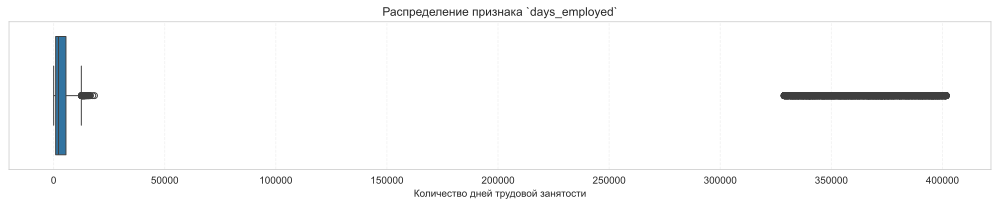

In [13]:
# визуализация распределения признака
plt.figure(figsize=(14, 3))
sns.boxplot(x=df['days_employed'], showfliers=True)
plt.title('Распределение признака `days_employed`')
plt.xlabel('Количество дней трудовой занятости')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Из данных графика становится очевидным существенный разрыв в значениях на интервале от `18388.949901` до `328728.720605`, при максимально допустимом значении `401755.400475`. Таким образом, максимальный порог естественных данных без искажений не достигает предполагаемой верхней отметки в 20 805 дней, и составляет 18 388 дней, или 50 лет.

Предлагаем рассмотреть, для каких типов занятости характеры аномалии длительности трудоустройства.

In [14]:
# делаем выборку с аномальными данными по дням трудовой занятости
out = df[df['days_employed'] > 19000]

In [15]:
# аномалии в признаке `days_employed` по типу занятости в общем массиве данных
df.groupby('income_type')['days_employed'].agg('median').sort_values(ascending=False).to_frame()

,days_employed
income_type,
безработный,366413.652744
пенсионер,365249.346345
в декрете,3296.759962
госслужащий,2689.137274
сотрудник,1573.203563
компаньон,1554.063508
студент,578.751554
предприниматель,520.848083


In [16]:
# аномалии в признаке `days_employed` по типу занятости в выбросах
out.groupby('income_type')['days_employed'].agg('median').sort_values(ascending=False).to_frame()

,days_employed
income_type,
безработный,366413.652744
пенсионер,365249.346345


Итак, мы получили информацию о том, что искажения данных присутствуют по двум типам трудовой занятости, это пенсионеры и безработные. Такого рода и качества данные, предположительно, могли быть получены банком по запросу из Социальных страховых фондов или иных аналогичных организаций. При этом, поля по трудовому стажу в первоначальном источнике могли означать не «текущий стаж», а «суммарное количество отработанных часов/дней за всю историю», включая дубликаты записей от разных работодателей. Или такие данные могли быть агрегированы сразу из нескольких источников, один и тот же период стажа мог быть учтён многократно. Либо произошёл некорректный парсинг дат, и при конвертации форматов дат (MM/DD/YYYY ↔ DD/MM/YYYY) могли «поехать» расчёты длительности.

Мы можем обработать эти данные, поскольку аномалии носят системный характер и описывают определённую однородную социальную группу людей в возрасте от 52 до 74 лет, без детей, без семьи, со средним образованием и средним доходом в год 137 147 долларов.

In [17]:
# базовая оценка по возрасту и образованию (строго с 18 лет)
start_age_map = {0: 18, 1: 18, 2: 19, 3: 22, 4: 25}
start_ages = df['education_id'].map(start_age_map).fillna(18)
df['base_exp'] = (df['dob_years'] - start_ages).clip(lower=0) * 240

In [18]:
# регрессионная коррекция на основе «чистых» данных
clean = df[df['days_employed'].between(1000, 20000)].copy()
clean['log_income'] = np.log1p(clean['total_income'].fillna(0))
clean['inc_code'] = pd.factorize(clean['income_type'])[0]

In [19]:
# разбиваем на выборки
X_train = clean[['base_exp', 'log_income', 'inc_code']].values
y_train = clean['days_employed'].values

In [20]:
# создаём и обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
# предсказываем скорректированные значения для всей выборки
df['log_income'] = np.log1p(df['total_income'].fillna(0))
df['inc_code'] = pd.factorize(df['income_type'])[0]
X_all = df[['base_exp', 'log_income', 'inc_code']].values
df['reg_pred'] = model.predict(X_all)

In [22]:
# гибридное сглаживание: 80% предметная логика, 20% статистические паттерны
alpha = 0.8
df['days_employed_hybrid'] = (alpha * df['base_exp'] + (1 - alpha) * df['reg_pred']).round()

In [23]:
# объективный физический потолок: максимальный возраст 74 − старт трудового стажа с 18 лет × 240 рабочих дней в году (по США)
max_days = (74 - 18) * 240  # = 13 440 дней (~37 лет)

df['days_employed_final'] = np.where(
    (df['days_employed'] > 20000) | (df['days_employed'] <= 0),
    df['days_employed_hybrid'].clip(0, max_days),
    df['days_employed']  # валидные записи не трогаем и сохраняем как есть
)

In [24]:
# убираем вспомогательные столбцы и отработанные исходные данные по `days_employed`
df.drop(columns=['base_exp', 'log_income', 'inc_code', 'reg_pred', 'days_employed_hybrid', 'days_employed'], inplace=True)

In [25]:
# проверка результатов трансформации данных
df.describe().round()

,children,dob_years,education_id,family_status_id,debt,total_income,days_employed_final
count,21448.0,21448.0,21448.0,21448.0,21448.0,19283.0,19283.0
mean,0.0,44.0,1.0,1.0,0.0,167416.0,3520.0
std,1.0,12.0,1.0,1.0,0.0,103044.0,3308.0
min,0.0,19.0,0.0,0.0,0.0,20667.0,24.0
25%,0.0,34.0,1.0,0.0,0.0,103013.0,928.0
50%,0.0,43.0,1.0,0.0,0.0,145018.0,2194.0
75%,1.0,53.0,1.0,1.0,0.0,203350.0,5464.0
max,5.0,75.0,4.0,4.0,1.0,2265604.0,18389.0


В обработанном массиве данных по-прежнему имеются пропуски значений в признаках `total_income` и `days_employed_final`. Пррименим логическую маску пропусков, чтобы убедиться, что пропуски в данных имеются в одних и тех же строках.

In [26]:
# подсчёт количества пропусков
df.isna().sum().sort_values(ascending=False)

total_income           2165
days_employed_final    2165
children                  0
dob_years                 0
education_id              0
education                 0
family_status             0
family_status_id          0
income_type               0
gender                    0
debt                      0
purpose                   0
dtype: int64

In [27]:
# логическая маска пропусков
df['total_income'].isna().equals(df['days_employed_final'].isna())

True

На сумму дохода сильнее всего влияет тип занятости, поэтому заполнить пропуски в столбце `total_income` нужно медианным значением по каждому типу из столбца `income_type`. Таким образом, у человека с типом занятости `сотрудник` пропуск в столбце `total_income` может быть заполнен медианным доходом среди всех записей с тем же типом.

In [28]:
# заполненение медианными значениями попусков в `total_income`
for i in df['income_type'].unique():
    df.loc[(df['income_type'] == i) & (df['total_income'].isna()), 'total_income'] = \
    df.loc[(df['income_type'] == i), 'total_income'].median()

Пропуски в данных о длительности трудового стажа `days_employed_final` заполним медианными значениями по типу занятости.

In [29]:
# заполнение медианными значениями пропусков в `days_employed` по каждому типу занятости
for i in df['income_type'].unique():
    df.loc[(df['income_type'] == i) & (df['days_employed_final'].isna()), 'days_employed_final'] = \
    df.loc[(df['income_type'] == i), 'days_employed_final'].median()

In [30]:
# проверка заполнения пропусков
df.isna().sum()

children               0
dob_years              0
education              0
education_id           0
family_status          0
family_status_id       0
gender                 0
income_type            0
debt                   0
total_income           0
purpose                0
days_employed_final    0
dtype: int64

<a id=2.3.></a>
### 2.3. Преобразование типов данных

Заменим тип данных в столбце `total_income` на целочисленный с помощью метода `astype()`.

In [31]:
# преобразование данных в целочисленный тип
df['total_income'] = df['total_income'].astype(int)

<a id=2.4.></a>
### 2.4. Обработка дубликатов

Проверим получившийся датафрейм на полные дубликаты.

In [32]:
# проверка на полные дубликаты
df.duplicated().sum()

np.int64(71)

In [33]:
# удаляем полные дубликаты
df = df.drop_duplicates()

<a id=2.5.></a>
### 2.5. Категоризация данных

На основании диапазонов, указанных ниже, необходимо создать в датафрейме новый признак `total_income_category` с категориями:

    0–30000 — 'E';
    30001–50000 — 'D';
    50001–200000 — 'C';
    200001–1000000 — 'B';
    1000001 и выше — 'A'.

Например, кредитополучателю с доходом 25000 нужно назначить категорию 'E', а клиенту, получающему 235000, — 'B'.

In [34]:
# создаём функцию для категоризации данных в соответствии с заданными условиями
def categorize_income(income):
    try:
        if 0 <= income <= 30000:
            return 'E'
        elif 30001 <= income <= 50000:
            return 'D'
        elif 50001 <= income <= 200000:
            return 'C'
        elif 200001 <= income <= 1000000:
            return 'B'
        elif income >= 1000001:
            return 'A'
    except:
        pass

In [35]:
# создаём новый признак путём применения функции категоризации данных
df['total_income_category'] = df['total_income'].apply(categorize_income)

In [36]:
# получаем уникальные цели получения кредита
df['purpose'].unique()

array(['покупка жилья', 'приобретение автомобиля',
       'дополнительное образование', 'сыграть свадьбу',
       'операции с жильем', 'образование', 'на проведение свадьбы',
       'покупка жилья для семьи', 'покупка недвижимости',
       'покупка коммерческой недвижимости', 'покупка жилой недвижимости',
       'строительство собственной недвижимости', 'недвижимость',
       'строительство недвижимости', 'на покупку подержанного автомобиля',
       'на покупку своего автомобиля',
       'операции с коммерческой недвижимостью',
       'строительство жилой недвижимости', 'жилье',
       'операции со своей недвижимостью', 'автомобили',
       'заняться образованием', 'сделка с подержанным автомобилем',
       'получение образования', 'автомобиль', 'свадьба',
       'получение дополнительного образования', 'покупка своего жилья',
       'операции с недвижимостью', 'получение высшего образования',
       'свой автомобиль', 'сделка с автомобилем',
       'профильное образование', 'высшее об

На основании данных из столбца `purpose_category` создадим функцию, которая сформирует новый столбец со следующими категориями:

    'операции с автомобилем',
    'операции с недвижимостью',
    'проведение свадьбы',
    'получение образования'.

Например, если в столбце purpose находится подстрока 'на покупку автомобиля', то в столбце `purpose_category` должна появиться строка 'операции с автомобилем'.

In [37]:
# создаём функцию для категоризации данных в соответствии с заданными условиями
def categorize_purpose(row):
    try:
        if 'автом' in row:
            return 'операции с автомобилем'
        elif 'жил' in row or 'недвиж' in row:
            return 'операции с недвижимостью'
        elif 'свад' in row:
            return 'проведение свадьбы'
        elif 'образов' in row:
            return 'получение образования'
    except:
        return 'нет категории'

In [38]:
# создаём новый признак путём применения функции категоризации данных
df['purpose_category'] = df['purpose'].apply(categorize_purpose)

In [39]:
# выведем информацию о размерности датафрейма после предобработки и очистки данных 
df.shape

(21377, 14)

**Выводы:** на данном этапе проекта была проведена комплексная работа по очистке, трансформации и обогащению исходного датасета с целью подготовки данных для анализа и перспективой дальнейшего построения прогнозной модели кредитного скоринга. Исходный набор данных, содержащий информацию о клиентах банка, требовал серьёзной доработки из-за наличия аномальных значений, пропусков, дубликатов и неструктурированных текстовых полей.

Работа началась с `фильтрации` заведомо некорректных записей: из выборки были исключены строки с неопределённым значением пола (`gender == 'XNA'`) и нереалистичным количеством детей (`children == 20`). Далее была проведена `нормализация` знаков в признаках `days_employed` и `children`: отрицательные значения, вероятнее всего возникшие вследствие технических ошибок при вводе или выгрузке данных, были приведены к модулю, что позволило сохранить наблюдения без искажения их смысла. Особое внимание было уделено признаку возраста `dob_years`, где нулевые значения, не имеющие физической интерпретации, были заменены медианными значениями, рассчитанными отдельно для каждой группы по типу занятости. Такой подход позволил учесть социально-экономическую неоднородность выборки и избежать искусственного смещения распределения возраста. Текстовые признаки `family_status` и `education` были приведены к нижнему регистру для обеспечения корректной группировки и последующего категориального кодирования.

Наиболее трудоёмкой частью предобработки стал анализ и коррекция признака `days_employed` (длительность трудового стажа в днях). Описательная статистика выявила экстремальное правостороннее смещение распределения: среднее значение составляло около 67 000 дней (примерно 183 года), тогда как медиана — лишь 2 196 дней (около 6 лет). Максимальное значение превышало 400 000 дней, что соответствует более чем тысячелетнему стажу и физически невозможно. Детальное исследование показало, что аномалии сконцентрированы в группах «пенсионер» и «безработный», что указывает на системную ошибку в источнике данных: вероятно, при агрегации учитывался суммарный стаж из нескольких источников, происходил некорректный парсинг дат или дублирование записей. Вместо простого удаления выбросов или их усечения был применён `гибридный подход`, сочетающий `предметную логику` и `статистическое моделирование`. Сначала для каждого клиента был рассчитан теоретически возможный стаж на основе разницы между текущим возрастом и минимальным возрастом начала трудовой деятельности, соответствующим уровню образования. Затем на подвыборке «чистых» данных (со стажем от 1 000 до 20 000 дней) была обучена `линейная регрессия`, предсказывающая стаж по возрасту, доходу и типу занятости. Итоговое значение для аномальных записей формировалось как взвешенная комбинация: 80% предметной оценки и 20% статистического предсказания, с обязательным ограничением сверху физически достижимым максимумом (~13 440 дней, что соответствует 37 годам стажа при 240 рабочих днях в году). В результате распределение признака `days_employed_final` стало правдоподобным: медиана составила около 6 лет, 75-й перцентиль — около 15 лет, при этом сохранилась дифференциация между социальными группами.

Пропущенные значения в признаках `total_income` и `days_employed_final` (по 2 165 пропусков в каждом) оказались полностью синхронизированы, что подтверждает их системный характер — отсутствие данных в первичном запросе к внешним источникам. Заполнение пропусков было выполнено медианными значениями, рассчитанными отдельно для каждого типа занятости (`income_type`). Такой подход учитывает существенные различия в структуре доходов между пенсионерами, госслужащими, наёмными сотрудниками и предпринимателями, минимизируя риск искусственного выравнивания распределения и искажения взаимосвязей с целевой переменной.

После обработки пропусков и аномалий датасет был проверен на наличие `полных дубликатов`: обнаружено и удалено 71 повторяющееся наблюдение, что исключает риск переобучения модели на идентичных записях. Признак `total_income` был `преобразован` в целочисленный тип, что оптимизирует использование памяти и обеспечивает корректную работу алгоритмов машинного обучения, чувствительных к типам данных.

Завершающим шагом этапа стала `генерация новых признаков`, направленных на повышение информативности данных и упрощение интерпретации моделей. На основе непрерывного признака дохода был создан категориальный признак `total_income_category` с пятью уровнями (от 'E' для доходов до 30 000 до 'A' для доходов свыше 1 000 000), что позволяет моделям легче улавливать нелинейные пороги платёжеспособности и упрощает сегментацию клиентов по уровню риска. Текстовое поле `purpose`, содержащее более 38 уникальных формулировок целей кредита, было агрегировано в новый признак `purpose_category` с четырьмя смысловыми группами: «операции с автомобилем», «операции с недвижимостью», «проведение свадьбы» и «получение образования». Это снизило размерность признака, устранило лексический шум и подготовило данные к эффективному категориальному кодированию.

По итогам предобработки размерность датасета составила 21 377 строк и 14 столбцов. Все пропуски устранены, дубликаты удалены, распределения числовых признаков стабилизированы и приведены к физически правдоподобным значениям, текстовые поля структурированы и категоризированы. Датасет полностью готов к следующему этапу — разведочному анализу и визуализации взаимосвязей.

<a id=3></a>
## Шаг 3. Исследовательский анализ данных

<a id=3.1.></a>
### 3.1. Общий уровень возвратности кредитных займов

In [40]:
# рассчитаем общий уровень возвратности кредитных займов
late_debt = df[(df['debt'] == 0)].count() / df['debt'].shape[0]
print('В {0:.2f}% случаев выплата кредитного займа клиентов была проведена своевременно.'.format(late_debt['debt'] * 100))

В 91.89% случаев выплата кредитного займа клиентов была проведена своевременно.


Указанный процент характеризует поведение клиентов на основании всех признаков датафрейма. Далее мы детально рассмотрим влияние определённого признака на целевой бинарный показатель своевременной выплаты кредита. Поскольку нам предстоит провести серию аналогичных исследований, полагаем необходимым создание универсальной функции.

In [41]:
# функция для исследования взаимосвязи целевого признака с каким-либо другим признаком
def debt_report(df, feature, target='debt', show_plot=True):
    """
    Функция для последовательного расчёта абсолютных и относительных значений 
    взаимосвязи целевой переменной с тем или иным признаком
    с последующей визуализацией графика риска невыплаты кредита.
    """
    # базовые метрики по всей выборке
    total_clients = len(df)
    total_0 = (df[target] == 0).sum()
    total_1 = df[target].sum()
    overall_rate = total_1 / total_clients if total_clients > 0 else 0

    # агрегация по категориям признака
    stats = df.groupby(feature)[target].agg(total='size', debt_1='sum').reset_index()
    stats.columns = ['Значение признака', 'Всего', '1 debt']
    
    stats['0 debt'] = stats['Всего'] - stats['1 debt']
    stats['0 debt, %'] = (stats['0 debt'] / stats['Всего'] * 100).round(2)
    stats['1 debt, %'] = (stats['1 debt'] / stats['Всего'] * 100).round(2)

    # во сколько раз риск выше среднего по всей базе клиентов
    stats['Lift'] = (stats['1 debt, %'] / (overall_rate * 100)).round(2)

    # сортировка: от самых рискованных клиентов к самым надёжным
    stats = stats.sort_values('1 debt, %', ascending=False).reset_index(drop=True)

    # вывод обобщённой таблицы с форматированием
    print(f"\n{'='*125}")
    print(f"Анализ взаимосвязи целевого признака `{target.upper()}` с признаком `{feature.upper()}`")
    print(f"{'='*125}")

    print(f"{'Значение признака':<30} | {'Всего, чел.':>10} | {'0 debt, чел.':>12} | {'1 debt, чел.':>12} | "
          f"{'0 debt, %':>9} | {'1 debt, %':>9} | {'Риск, %':>8} | {'Lift, х':>7}")
    print("-" * 125)

    # цветовые маркеры для наглядности искомых значений
    for _, row in stats.iterrows():
        cat_name = str(row['Значение признака'])[:30].ljust(30)
        marker = "🔴" if row['1 debt, %'] > overall_rate * 100 else "🟢"
        
        print(f"{cat_name} | {int(row['Всего']):>10,} | {int(row['0 debt']):>12,} | {int(row['1 debt']):>12,} | "
              f"{row['0 debt, %']:>8.2f}% | {row['1 debt, %']:>8.2f}% | "
              f"{row['1 debt, %']:>7.2f}% {marker} | {row['Lift']:>6.2f}x")

    print("-" * 125)
    
    # итоговая строка
    overall_0_pct = (total_0 / total_clients * 100)
    overall_1_pct = overall_rate * 100
    print(f"{'ИТОГО / СРЕДНЕЕ':<30} | {total_clients:>10,} | {total_0:>12,} | {total_1:>12,} | "
          f"{overall_0_pct:>8.2f}% | {overall_1_pct:>8.2f}% | "
          f"{overall_1_pct:>7.2f}%    | {'1.00':>6.2}x")
          
    # визаулизация взаимосвязи целевого признака сзаданным признаком
    if show_plot:
        print("\n" * 3) # широкий отступ между таблицей и графиком
        
        plt.figure(figsize=(10, 4))
        colors = ['#e74c3c' if rate > overall_rate * 100 else '#27ae60' 
                  for rate in stats['1 debt, %']]
        
        # столбцы диаграммы
        bars = plt.barh(stats['Значение признака'].astype(str), 
                        stats['1 debt, %'], color=colors, 
                        edgecolor='gray', alpha=0.7, height=0.5)
        
        # вертикальный отбойник среднего уровня риска по всей базе
        plt.axvline(x=overall_rate * 100, color='blue', linestyle='--', 
                    linewidth=1, label=f'Средний риск: {overall_rate*100:.2f}%')
        
        # подписи рядом со столбцами
        for bar, rate in zip(bars, stats['1 debt, %']):
            plt.text(rate + 0.1, bar.get_y() + bar.get_height()/2, 
                     f'{rate:.2f}%', va='center', 
                     fontsize=9, fontweight='bold')
        
        plt.title(f'Риск невозврата кредита по признаку `{feature}`', fontsize=12, fontweight='bold', pad=20)
        plt.xlabel('Доля дефолтов (1 debt), %', fontsize=11)
        plt.legend(loc='lower right', fontsize=9)
        plt.grid(axis='x', alpha=0.3, linestyle=':')
        plt.xlim(0, max(stats['1 debt, %']) * 1.2)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

<a id=3.2.></a>
### 3.2. Есть ли зависимость между количеством детей и возвратом кредита в срок?


Анализ взаимосвязи целевого признака `DEBT` с признаком `CHILDREN`
Значение признака              | Всего, чел. | 0 debt, чел. | 1 debt, чел. | 0 debt, % | 1 debt, % |  Риск, % | Lift, х
-----------------------------------------------------------------------------------------------------------------------------
4.0                            |         41 |           37 |            4 |    90.24% |     9.76% |    9.76% 🔴 |   1.20x
2.0                            |      2,052 |        1,858 |          194 |    90.55% |     9.45% |    9.45% 🔴 |   1.17x
1.0                            |      4,855 |        4,410 |          445 |    90.83% |     9.17% |    9.17% 🔴 |   1.13x
3.0                            |        330 |          303 |           27 |    91.82% |     8.18% |    8.18% 🔴 |   1.01x
0.0                            |     14,090 |       13,027 |        1,063 |    92.46% |     7.54% |    7.54% 🟢 |   0.93x
5.0                            |          9 |            9 |            0 |   100

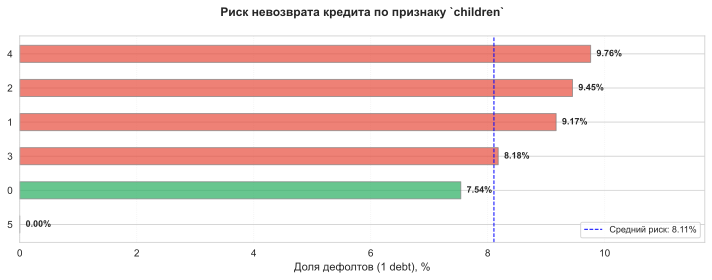

In [42]:
# исследование зависимости между уровнем дохода и невыплатой кредита в установленный срок
debt_report(df, 'children', target='debt')

**Вывод:** исследование взаимосвязи между количеством детей `children` и наличием просроченной задолженности `debt` выявляет устойчивую закономерность: **наличие детей в семье ассоциируется с повышенным кредитным риском**, причём эта зависимость носит нелинейный характер и достигает максимума при одном–двух детях.

Базовый уровень дефолта по всей выборке составляет `8,11%`. Клиенты, не имеющие детей, демонстрируют наиболее благоприятный профиль риска: доля просрочек в этой группе равна `7,54%` (Lift 0,93x), что ниже среднего показателя. При этом **на категорию клиентов без детей приходится подавляющая часть портфеля — 14 090 клиентов из 21 377 (около 66%)**, что делает её ключевой с точки зрения объёма и стабильности.

С появлением в семье первого ребёнка уровень риска заметно возрастает: среди клиентов с одним ребёнком доля дефолтов составляет `9,17%` (Lift 1,13x). При двух детях риск достигает пика — `9,45%` (Lift 1,17x). Обе группы статистически значимы по численности (4 855 и 2 052 наблюдения соответственно), что позволяет с уверенностью интерпретировать выявленную тенденцию. Вероятными объяснениями служат рост финансовой нагрузки, связанной с содержанием и образованием детей, а также возможное снижение финансовой гибкости домохозяйства при непредвиденных расходах.

В группах с тремя и более детьми картина становится менее однозначной из-за существенного сокращения размера выборки. Так, при трёх детях (330 клиентов) уровень дефолта составляет `8,18%` — практически на среднем уровне. При четырёх детях (41 наблюдение) риск формально достигает максимума — `9,76%`, однако малая численность группы не позволяет делать статистически надёжные выводы. Особого внимания требует категория с пятью детьми: при всего 9 наблюдениях зафиксировано `0%` дефолтов, что, скорее всего, отражает не реальную безрисковость, а эффект малой выборки.

Таким образом, признак `children` демонстрирует **чёткую дифференциацию риска между клиентами `без детей` и клиентами `с детьми`**, особенно с одним–двумя. Для целей моделирования целесообразно рассмотреть бинарное или групповое кодирование признака: например, разделение на «0 детей» (низкий риск) и «1+ детей» (повышенный риск), либо трёхуровневую группировку: «0», «1–2», «3 и более». Такой подход позволит сохранить информативность признака, избежать переобучения на малочисленных категориях и упростить интерпретацию модели. Кроме того, при использовании признака количества детей в скоринговой модели мы рекомендуем обязательно учитывать его взаимодействие с другими переменными: типом занятости, семейным положением и категорией дохода. Например, риск, связанный с наличием детей, может по-разному проявляться у одиноких родителей и полных семей, у клиентов с высоким и низким уровнем дохода. Интеграция `children` в состав сложных признаков или использование алгоритмов, способных автоматически выявлять нелинейные взаимодействия (например, градиентный бустинг), может дополнительно повысить прогнозную силу модели.

<a id=3.3.></a>
### 3.3. Есть ли зависимость между семейным положением и возвратом кредита в срок?


Анализ взаимосвязи целевого признака `DEBT` с признаком `FAMILY_STATUS`
Значение признака              | Всего, чел. | 0 debt, чел. | 1 debt, чел. | 0 debt, % | 1 debt, % |  Риск, % | Lift, х
-----------------------------------------------------------------------------------------------------------------------------
не женат / не замужем          |      2,801 |        2,528 |          273 |    90.25% |     9.75% |    9.75% 🔴 |   1.20x
гражданский брак               |      4,138 |        3,753 |          385 |    90.70% |     9.30% |    9.30% 🔴 |   1.15x
женат / замужем                |     12,290 |       11,362 |          928 |    92.45% |     7.55% |    7.55% 🟢 |   0.93x
в разводе                      |      1,193 |        1,109 |           84 |    92.96% |     7.04% |    7.04% 🟢 |   0.87x
вдовец / вдова                 |        955 |          892 |           63 |    93.40% |     6.60% |    6.60% 🟢 |   0.81x
----------------------------------------------------------------------------

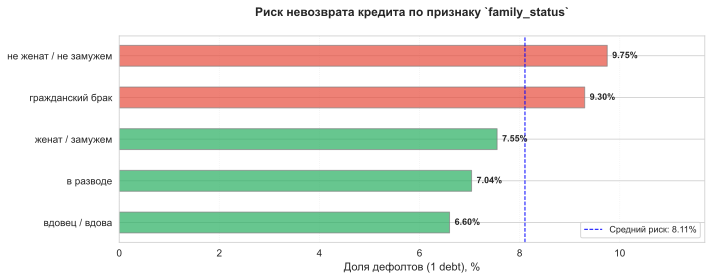

In [43]:
# исследование зависимости между семейным положением и невыплатой кредита в установленный срок
debt_report(df, 'family_status', target='debt')

**Вывод:** исследование взаимосвязи между семейным положением клиента `family_status` и наличием просроченной задолженности `debt` выявляет выраженную дифференциацию кредитного риска в зависимости от статуса отношений. Общий уровень дефолта по выборке составляет `8,11%`, однако при детальной разбивке по категориям семейного положения проявляется чёткая закономерность: **клиенты, не имеющие официально зарегистрированного брака, демонстрируют существенно более высокий риск неплатежа.**

Наиболее уязвимой группой являются клиенты со статусом «не женат / не замужем»: доля просрочек в этой категории достигает `9,75%` (Lift 1,20x), что на 20% выше среднего показателя по портфелю. Чуть ниже, но всё же выше среднего, риск у клиентов, состоящих в гражданском браке: `9,30%` (Lift 1,15x). Обе группы вместе составляют около 33% от общей выборки (6 939 клиентов из 21 377), при этом их вклад в общий объём дефолтов непропорционально велик. Вероятными объяснениями служат меньшая финансовая стабильность, более низкий уровень совместного планирования бюджета или меньшая склонность к долгосрочным финансовым обязательствам у клиентов, не вступивших в официальный брак.

Противоположную картину демонстрируют **клиенты, состоящие в зарегистрированном браке**: уровень дефолта в этой группе составляет `7,55%` (Lift 0,93x), что ниже среднего показателя. При этом данная категория является **доминирующей по численности** — 12 290 клиентов, или около 57% всей выборки, — и именно она **в значительной степени определяет общий профиль риска портфеля.** Ещё более низкие значения риска фиксируются у клиентов, прошедших через потерю партнёра или расторжение брака: у разведённых уровень дефолтов равен `7,04%` (Lift 0,87x), у вдовцов и вдов — `6,60%` (Lift 0,81x), что является минимальным показателем среди всех категорий. Такой результат может отражать более консервативное финансовое поведение, сформированное в результате жизненных испытаний: эти клиенты склонны тщательнее оценивать свои обязательства и избегать излишней кредитной нагрузки.

Важно отметить, что выявленная градация риска — от максимального у холостых к минимальному у вдовцов — не обязательно свидетельствует о причинно-следственной связи между семейным статусом и платёжной дисциплиной. Скорее всего, **семейное положение выступает маркером более широкого комплекса факторов**: возраста, уровня финансовой зрелости, социальной стабильности и психологической готовности к долгосрочным обязательствам. Например, клиенты в категории «вдовец / вдова» в среднем старше, имеют устоявшиеся финансовые привычки и меньшую склонность к импульсивным займам.

Для целей построения скоринговой модели **признак `family_status` представляет высокую ценность как в исходном виде, так и в виде агрегированных групп.** Целесообразно рассмотреть бинарное кодирование: «официальный брак / вдовство» (низкий риск) против «холост / гражданский брак / развод» (повышенный риск), либо трёхуровневую группировку с выделением наиболее рискованной категории «не женат / не замужем». Такой подход позволит сохранить информативность признака, снизить размерность и упростить интерпретацию модели без существенной потери прогнозной силы. Кроме того, при интеграции признака в модель рекомендуется протестировать его взаимодействие с другими переменными: наличием детей, типом занятости и категорией дохода. Например, риск, связанный с отсутствием официального брака, может усиливаться у клиентов с низким доходом и несколькими детьми, тогда как у высокооплачиваемых специалистов этот эффект может быть нивелирован. Алгоритмы, способные автоматически выявлять нелинейные взаимодействия (например, градиентный бустинг или нейросетевые архитектуры), могут дополнительно раскрыть потенциал признака `family_status` для повышения точности прогноза кредитного дефолта.

<a id=3.4.></a>
### 3.4. Есть ли зависимость между уровнем дохода и возвратом кредита в срок?


Анализ взаимосвязи целевого признака `DEBT` с признаком `TOTAL_INCOME_CATEGORY`
Значение признака              | Всего, чел. | 0 debt, чел. | 1 debt, чел. | 0 debt, % | 1 debt, % |  Риск, % | Lift, х
-----------------------------------------------------------------------------------------------------------------------------
E                              |         22 |           20 |            2 |    90.91% |     9.09% |    9.09% 🔴 |   1.12x
C                              |     15,959 |       14,605 |        1,354 |    91.52% |     8.48% |    8.48% 🔴 |   1.05x
A                              |         25 |           23 |            2 |    92.00% |     8.00% |    8.00% 🟢 |   0.99x
B                              |      5,021 |        4,667 |          354 |    92.95% |     7.05% |    7.05% 🟢 |   0.87x
D                              |        350 |          329 |           21 |    94.00% |     6.00% |    6.00% 🟢 |   0.74x
--------------------------------------------------------------------

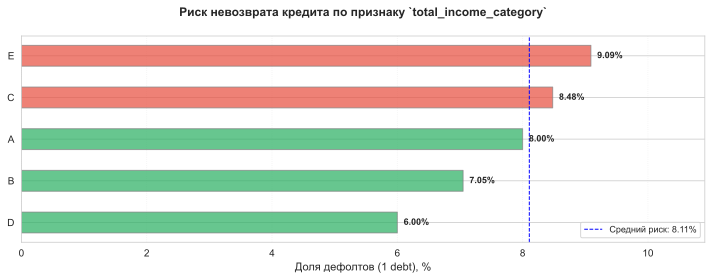

In [44]:
# исследование зависимости между уровнем дохода и невыплатой кредита в установленный срок
debt_report(df, 'total_income_category', target='debt')

**Вывод:** проведённый анализ взаимосвязи целевого признака наличие просроченной задолженности `debt` с категоризованным признаком дохода `total_income_category` позволяет сделать ряд важных выводов о структуре кредитного риска в исследуемой выборке. Общий уровень дефолта по всей совокупности клиентов составляет `8,11%`, однако при детальной разбивке по доходным группам проявляется выраженная нелинейная **зависимость**, которая **не укладывается в упрощённое представление «чем выше доход — тем ниже риск».**

Наиболее высокий уровень просрочки наблюдается в двух группах: клиенты с наименьшим доходом (`категория 'E'`, 0–30 000) и клиенты со средним доходом (`категория 'C'`, 50 001–200 000). В первой группе доля дефолтов достигает `9,09%` (Lift 1,12x), во второй — `8,48%` (Lift 1,05x). При этом категория 'C' является доминирующей по численности: на неё приходится почти 75% всей выборки (15 959 клиентов из 21 377), что означает, что именно **группа клиентов с категорией 'C' в наибольшей степени формирует общий профиль риска портфеля.** Повышенная уязвимость клиентов со средним доходом может объясняться более высокой кредитной нагрузкой: имея доступ к большим лимитам, они чаще берут кредиты на значительные суммы, что при возникновении непредвиденных обстоятельств повышает вероятность просрочки.

Интересным и неочевидным результатом является то, что **наименьший уровень дефолта зафиксирован не в самой высокой доходной группе, а в категории 'D'** (30 001–50 000), где риск составляет всего `6%` (Lift 0,74x). Это может свидетельствовать о более консервативном финансовом поведении данной группы: клиенты с умеренным, но стабильным доходом склонны брать кредиты строго под конкретные, заранее спланированные нужды и тщательнее оценивают свою платёжеспособность. Группа с высоким доходом (`категория 'B'`, 200 001–1 000 000) также демонстрирует сниженный риск — `7,05%` (Lift 0,87x), что согласуется с ожиданиями: финансовая подушка и более высокий уровень доходов обеспечивают большую устойчивость к временным трудностям.

Что касается клиентов с экстремально высоким доходом (`категория 'A'`, свыше 1 000 000), то их доля дефолтов составляет `8%`, что близко к среднему по выборке. Однако интерпретировать этот результат следует с осторожностью: в данной категории представлено всего 25 наблюдений, поэтому статистическая погрешность оценки весьма велика. Аналогичная ситуация характерна и для `категории 'E'` (всего 22 клиента), где высокий процент дефолтов также может быть в значительной степени обусловлен малым размером выборки.

Таким образом, анализ подтверждает, что доход, даже в категоризованном виде, не является линейным предиктором кредитного дефолта. Риск формируется под воздействием комплекса факторов: финансовой дисциплины, структуры обязательств, целей кредитования и поведенческих паттернов, которые могут по-разному проявляться в различных доходных сегментах. Для построения устойчивой модели кредитного скоринга признак `total_income_category` целесообразно использовать не изолированно, а в комбинации с другими переменными: типом занятости, семейным положением, целью кредита и учётом историей платежей. Кроме того, при валидации модели следует учитывать дисбаланс численности групп: доминирующая категория 'C' может чрезмерно влиять на метрики качества, поэтому рекомендуется применять взвешенные функции потерь или стратифицированную кросс-валидацию для обеспечения репрезентативной оценки по всем сегментам клиентов.

<a id=3.5.></a>
### 3.5. Как разные цели кредита влияют на его возврат в срок?


Анализ взаимосвязи целевого признака `DEBT` с признаком `PURPOSE_CATEGORY`
Значение признака              | Всего, чел. | 0 debt, чел. | 1 debt, чел. | 0 debt, % | 1 debt, % |  Риск, % | Lift, х
-----------------------------------------------------------------------------------------------------------------------------
операции с автомобилем         |      4,290 |        3,889 |          401 |    90.65% |     9.35% |    9.35% 🔴 |   1.15x
получение образования          |      3,998 |        3,629 |          369 |    90.77% |     9.23% |    9.23% 🔴 |   1.14x
проведение свадьбы             |      2,315 |        2,132 |          183 |    92.10% |     7.90% |    7.90% 🟢 |   0.97x
операции с недвижимостью       |     10,774 |        9,994 |          780 |    92.76% |     7.24% |    7.24% 🟢 |   0.89x
-----------------------------------------------------------------------------------------------------------------------------
ИТОГО / СРЕДНЕЕ                |     21,377 |       19,644 |        

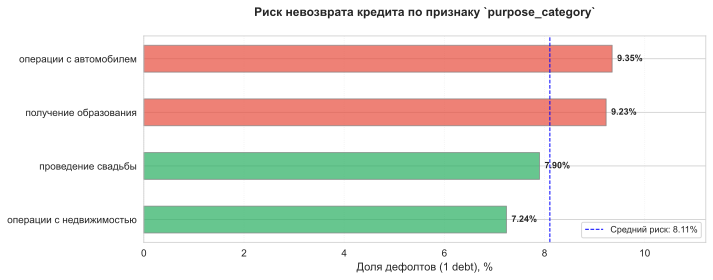

In [45]:
# исследование зависимости между уровнем дохода и невыплатой кредита в установленный срок
debt_report(df, 'purpose_category', target='debt')

**Вывод:** исследование взаимосвязи между категоризованной целью получения кредита `purpose_category` и наличием просроченной задолженности `debt` демонстрирует выраженную дифференциацию риска в зависимости от назначения заёмных средств. При детальной разбивке по целям кредита выявляются **две отчётливые группы: направления с повышенным риском и направления с уровнем риска ниже среднего.**

**Наиболее рискованными категориями являются «операции с автомобилем» и «получение образования».** В первой группе доля просрочек достигает `9,35%` (Lift 1,15x), во второй — `9,23%` (Lift 1,14x). Обе категории статистически значимы по численности: 4 290 и 3 998 клиентов соответственно, что позволяет с уверенностью интерпретировать выявленную закономерность. Повышенный риск по автокредитам может объясняться рядом факторов: автомобиль является быстрообесценивающимся активом, что снижает мотивацию к приоритетному погашению займа в случае финансовых трудностей; кроме того, данная категория клиентов может быть более склонна к импульсивным решениям и недооценке долгосрочной кредитной нагрузки. Что касается образовательных кредитов, то высокий уровень дефолтов, вероятнее всего, связан с длительным горизонтом окупаемости вложений: заёмщики сталкиваются с задержками в трудоустройстве, несоответствием ожидаемого и фактического дохода после обучения или изменением жизненных планов, что затрудняет своевременное обслуживание долга.

**Противоположную картину демонстрируют цели, связанные с недвижимостью и проведением свадьбы.** Категория «операции с недвижимостью» является доминирующей по объёму: на неё приходится более половины всей выборки (10 774 клиента из 21 377, или около 50%), при этом уровень дефолта в этой группе составляет всего `7,24%` (Lift 0,89x) — минимальное значение среди всех категорий. Низкий риск, вероятнее всего, обусловлен наличием залогового обеспечения, более тщательным предварительным планированием сделки, а также высокой личной заинтересованностью клиента в сохранении платёжной дисциплины ради сохранения имущества. Категория «проведение свадьбы» (2 315 клиентов) также демонстрирует риск ниже среднего — `7,9%` (Lift 0,97x), что может отражать высокую мотивацию клиентов сохранить финансовую репутацию в период начала совместной жизни, а также наличие финансовой поддержки со стороны родственников.

Важно отметить, что выявленная градация риска не обязательно свидетельствует о прямой причинно-следственной связи между целью кредита и платёжной дисциплиной. Скорее всего, **цель займа выступает маркером более широкого комплекса характеристик**: суммы кредита, срока погашения, наличия залога, уровня финансовой грамотности и поведенческих паттернов заёмщика. Например, клиенты, берущие кредит на недвижимость, в среднем старше, имеют более стабильный доход и долгосрочное финансовое планирование, тогда как заёмщики на автомобиль или образование могут быть моложе и менее опытны в управлении обязательствами.

Для целей построения скоринговой модели признак `purpose_category` представляет высокую прогнозную ценность и может быть использован как в исходном виде (с применением One-Hot или Target Encoding), так и в виде бинарной группировки: «повышенный риск» (автомобиль, образование) против «пониженный риск» (недвижимость, свадьба). Такой подход позволит сохранить информативность признака, снизить размерность и упростить интерпретацию модели без потери прогнозной силы. При интеграции признака в модель рекомендуется протестировать его взаимодействие с другими переменными: категорией дохода, типом занятости и семейным положением. Например, риск по образовательному кредиту может существенно различаться у студентов и у работающих специалистов, проходящих переподготовку; риск по автокредиту — у клиентов с высоким и низким доходом. Алгоритмы, способные автоматически выявлять нелинейные взаимодействия (например, градиентный бустинг), могут дополнительно раскрыть потенциал признака purpose_category для повышения точности прогноза. С практической точки зрения полученные результаты могут служить основанием для дифференциации кредитной политики: ужесточения требований к заёмщикам, указывающим цели «автомобиль» или «образование» (например, требование созаёмщика, снижение максимального соотношения платежа к доходу), и, напротив, предложения более гибких условий по ипотечным и свадебным кредитам, где риск дефолта статистически ниже. Такой сегментированный подход позволит оптимизировать баланс между объёмом выдач и качеством кредитного портфеля.

<a id=4></a>
## Шаг 4. Вывод

Закредитованность населения является одной из глобальных мировых тенденций современности. Поэтому оценка кредитоспособности клиента является важным и неотъемлемым направлением деятельности банков, поскольку лежит в основе самого принципа возвратности кредита, и, следовательно, тех доходов, которые рассчитывает получить банк.

В целях получения информации о потенциале платёжеспособности клиента, работники банка оценивают в порядке приоритетности уровень заработка клиента, возраст, трудовой стаж, уровень образования, цель кредита, семейное положение и количество детей при их наличии. Все эти параметры формируют так называемую скоринговую систему, исходя из которой клиенту кредит может быть предоставлен системой автоматически, либо наоборот, для рассмотрения заявки потребуется участие специалиста банка в очной форме.

В целях выполнения задачи по исследованию надежности заёмщиков была импортирована библиотека `pandas` для работы с массивами данных, `matplotlib` и `seaborn` для визуализации полученных результатов, осуществлена загрузка исходного файла с данными. В работу поступил датафрейм `data.csv`, в котором содержатся 21 525 записей банковских данных клиентов в разрезе 12 признаков.

Целевым является бинарный признак наличия либо отсутствия задолженности по выплате кредитного займа `debt`. Первичный описательный анализ данных выполнен с помощью метода `info()`. Поскольку исходный датасет содержал существенные проблемы качества данных, нами был выполнен комплекс работ по предварительной обработке и очистке данных. Признак `days_employed` демонстрировал экстремальные аномалии (значения до 1 100 лет стажа), которые были устранены с применением гибридного подхода, сочетающего предметную логику (расчёт максимально возможного стажа на основе возраста и образования) и статистическое моделирование. Пропущенные значения в `total_income` и `days_employed` (около 10% наблюдений) имели системный характер и были заполнены медианами по группам типа занятости, что позволило сохранить социально-экономическую неоднородность выборки. Выполнено преобразование типов данных из вещественного в целочисленный по признаку `total_income`, преобразован регистр записей к нижнему по признаку `family_status`. Обработаны и удалены неявные дубликаты данных по признаку `education`. Проведена категоризация данных: создан дополнительный признак `total_income_category`. По итогам лемматизации всех изначально указанных формулировок цели получения кредита, был создан дополнительный признак `purpose_category`, хранящий данные по 4 укрупнённым категориям, а именно: «операции с автомобилем», «операции с недвижимостью», «получение образования», «проведение свадьбы». После удаления дубликатов и фильтрации некорректных записей итоговый датасет содержит 21 377 наблюдений без пропусков и готов к исследованию.

Перед нами был поставлен ряд исследовательских задач по выявлению зависимости между целевым признаком возврата кредита в срок `debt` и рядом других признаков, таких, как количество детей `children`, семейное положение `family_status`, уровень дохода `total_income`, цель получения кредита `purpose`. Вероятность своевременного возврата кредитного займа в разрезе всего массива данных составляет 91.89%. Подробные расчёты вероятности в разрезе вышеназванных признаков приведены в таблице ниже.

*Таблица 1. Расчёт вероятности возврата кредитного займа по признакам*

<table>
  <thead>
    <tr>
      <th><code>children</code></th>
      <th><code>family_status</code></th>
      <th><code>total_income_category</code></th>
      <th><code>purpose</code></th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #d4edda;">
      <td>100.00% <em>5 детей в семье</em></td>
      <td></td>
      <td></td>
      <td></td>
    </tr>
    <tr style="background-color: #d4edda;">
      <td></td>
      <td>93.40% <em>вдова / вдовец</em></td>
      <td>94.00% <em>категория D</em></td>
      <td></td>
    </tr>
    <tr style="background-color: #d4edda;">
      <td>92.46% <em>бездетная семья (0)</em></td>
      <td>92.96% <em>в разводе</em></td>
      <td>92.95% <em>категория B</em></td>
      <td>92.76% <em>операции с недвижимостью</em></td>
    </tr>
    <tr style="background-color: #d4edda;">
      <td></td>
      <td>92.45% <em>женатые / замужние</em></td>
      <td>92.00% <em>категория A</em></td>
      <td>92.10% <em>проведение свадьбы</em></td>
    </tr>
    <tr style="background-color: #f8d7da;">
      <td>91.82% <em>3 ребёнка в семье</em></td>
      <td></td>
      <td>91.52% <em>категория C</em></td>
      <td>91.89% <em>общий уровень</em></td>
    </tr>
    <tr style="background-color: #f8d7da;">
      <td>90.83% <em>1 ребёнок в семье</em></td>
      <td>90.70% <em>в гражданском браке</em></td>
      <td>90.91% <em>категория E</em></td>
      <td>90.77% <em>получение образования</em></td>
    </tr>
    <tr style="background-color: #f8d7da;">
      <td>90.55% <em>2 ребёнка в семье</em></td>
      <td></td>
      <td></td>
      <td>90.65% <em>операции с автомобилем</em></td>
    </tr>
    <tr style="background-color: #f8d7da;">
      <td>90.24% <em>4 ребёнка в семье</em></td>
      <td>90.25% <em>не женатые / не замужние</em></td>
      <td></td>
      <td></td>
    </tr>
  </tbody>
</table>

В полученных расчётах присутствует ярко выраженный градиент, который затрагивает каждый признак и формирует определённый социальный портрет клиента, который принесёт банку либо дополнительную прибыль, либо дополнительную головную боль в случае несвоевременного возврата кредитного займа. Анализ взаимосвязей с целевой переменной выявил, что кредитный риск формируется под воздействием комплекса демографических, социальных и поведенческих факторов, причём зависимости часто носят нелинейный характер.

<input type="checkbox" checked disabled> Доход `total_income_category` не является линейным предиктором дефолта. Наименьший риск зафиксирован в категории 'D' (30 001–50 000) — 6,00%, что может отражать консервативное финансовое поведение клиентов с умеренным, но стабильным доходом. Группы с минимальным ('E') и средним ('C') доходом демонстрируют повышенный риск (9,09% и 8,48% соответственно), причём категория 'C' формирует основную массу портфеля и, следовательно, определяет его общий профиль риска.

<input type="checkbox" checked disabled> Наличие детей `children` показывает устойчивую положительную связь с уровнем дефолта: клиенты без детей имеют риск 7,54%, тогда как наличие одного–двух детей повышает риск до 9,17–9,45%. Это согласуется с гипотезой о росте финансовой нагрузки и снижении гибкости бюджета в семьях с детьми. При этом группы с тремя и более детьми малочисленны, что требует осторожности в интерпретации.

<input type="checkbox" checked disabled> Семейное положение `family_status` демонстрирует наиболее выраженную градацию риска: от максимального уровня у холостых клиентов (9,75%) к минимальному у вдовцов (6,60%). Официальный брак ассоциируется с более низкой вероятностью дефолта (7,55%), что может отражать не только финансовую стабильность, но и более высокую склонность к долгосрочному планированию и ответственности. При этом семейный статус, вероятнее всего, выступает маркером более широкого комплекса характеристик (возраст, финансовая зрелость, социальная интеграция), а не прямой причиной изменения платёжного поведения.

<input type="checkbox" checked disabled> Цель кредита `purpose_category` выявляет два контрастных кластера риска. Кредиты на автомобиль и образование демонстрируют повышенный уровень дефолта (9,35% и 9,23%), что может объясняться быстрым обесцениванием актива (автомобиль) или длительным горизонтом окупаемости вложений (образование). Напротив, операции с недвижимостью (7,24%) и проведение свадьбы (7,90%) ассоциируются с риском ниже среднего, вероятно, благодаря наличию залогового обеспечения, более тщательному планированию и высокой личной мотивации заёмщика.

В целях подготовки к реализации скоринговой модели, мы можем отметить **приоритетные признаки с наибольшей прогнозной ценностью: `family_status`, `purpose_category` и `children`** — они показывают устойчивую дифференциацию риска при достаточном объёме наблюдений. Признак дохода `total_income_category` целесообразно использовать в комбинации с другими переменными, так как его влияние носит опосредованный характер.
    
Для категориальных признаков рекомендуется применять целевое кодирование (Target Encoding) или частотное кодирование, особенно для `purpose_category` и `family_status`, чтобы сохранить информативность порядковых зависимостей. Признак `children` целесообразно сгруппировать: «0 детей» / «1–2 ребёнка» / «3 и более», чтобы избежать переобучения на малочисленных категориях.

Выявленные в ходе исследования **закономерности указывают на важность нелинейных взаимодействий**: например, риск, связанный с наличием детей, может усиливаться при низком доходе и отсутствии официального брака. При построении модели рекомендуется использовать алгоритмы, способные автоматически выявлять такие паттерны (градиентный бустинг, случайный лес), либо вручную создавать кросс-признаки.

Результаты данного исследования также могут быть эффективно применены для актуализации кредитной политики и сегментирования клиентов: ужесточение требований для заявок с целями «автомобиль» / «образование» и для клиентов без официального брака; предложение более гибких условий по ипотечным продуктам и кредитам на свадьбу, где риск статистически ниже.

Полагаем важным отметить определённые ограничения в дальнейшей работе с этим направлением. Отдельные категории (например, `total_income_category` 'A' и 'E', `children == 5`) представлены малым числом наблюдений, что снижает надёжность оценок риска. В будущих итерациях целесообразно привлечь дополнительные данные или применить методы сглаживания (Bayesian shrinkage). Также рекомендуется провести анализ выживаемости (survival analysis) для оценки динамики дефолтов во времени и проверить влияние макроэкономических факторов на стабильность выявленных закономерностей.

Проведённое исследование подтвердило, что **кредитный риск не определяется одним изолированным фактором, а формируется в результате сложного взаимодействия демографических, социальных и поведенческих характеристик заёмщика.** Успешная модель скоринга должна учитывать эту многомерность: использовать предметно-обоснованные преобразования признаков, сохранять интерпретируемость ключевых зависимостей и применять алгоритмы, устойчивые к дисбалансу классов и нелинейным эффектам. Подготовленный и проанализированный датасет полностью готов к следующему этапу — построению, валидации и внедрению прогнозной модели.